In [1]:
!pip install pandas numpy scikit-learn nltk


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import ipywidgets as widgets
from IPython.display import display


In [3]:
## Load Dataset
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
## Text Cleaning
def clean_text(text):
    text = str(text).lower()
    
    # Remove specific bias words
    text = re.sub(r'reuters', '', text)
    
    # Normal cleaning
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    
    return text.strip()

data["text"] = data["text"].apply(clean_text)

In [19]:
## Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

In [20]:
## Build Pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=3000,
        min_df=3,
        max_df=0.8,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("svm", LinearSVC(C=0.5))
])

In [21]:
## Train SVM Model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [22]:
## Evaluate Model
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report:\n", classification_report(y_test, test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, test_pred))

Training Accuracy: 0.993457319449858
Test Accuracy: 0.9853006681514477

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.98      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Matrix:
 [[4618   78]
 [  54 4230]]


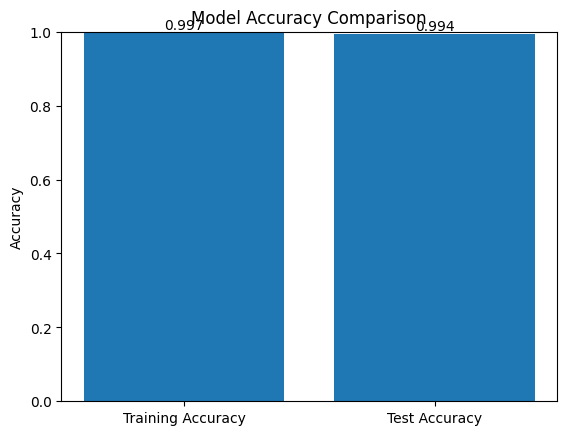

In [9]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

labels = ["Training Accuracy", "Test Accuracy"]
values = [train_acc, test_acc]

plt.figure()
plt.bar(labels, values)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

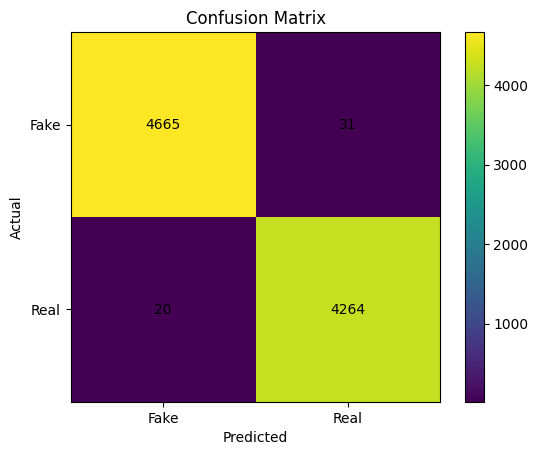

In [10]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Fake", "Real"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

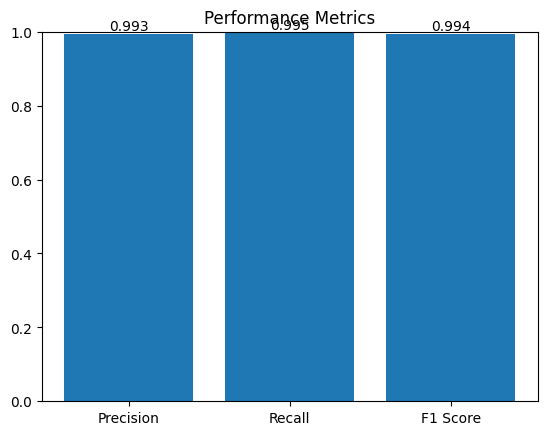

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

metrics = ["Precision", "Recall", "F1 Score"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Performance Metrics")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

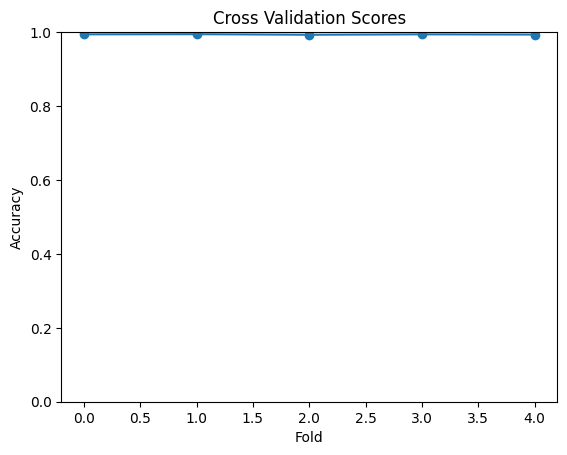

Average CV Accuracy: 0.9937413678191455


In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, data["text"], data["label"], cv=5)

plt.figure()
plt.plot(cv_scores, marker='o')
plt.title("Cross Validation Scores")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

print("Average CV Accuracy:", cv_scores.mean())

In [14]:
!pip install ipywidgets

^C


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Text input field
news_input = widgets.Textarea(
    value='',
    placeholder='Type news article here...',
    description='News:',
    layout=widgets.Layout(width='600px', height='150px')
)

# Button
check_button = widgets.Button(
    description="Check News",
    button_style='success'
)

# Output area
output = widgets.Output()

In [25]:
def check_news(b):
    with output:
        output.clear_output()
        
        news = news_input.value
        prediction = model.predict([clean_text(news)])
        
        if prediction[0] == 0:
            print("FAKE NEWS")
        else:
            print("REAL NEWS")

check_button.on_click(check_news)

display(news_input, check_button, output)

Textarea(value='', description='News:', layout=Layout(height='150px', width='600px'), placeholder='Type news a…

Button(button_style='success', description='Check News', style=ButtonStyle())

Output()